In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df_inf = pd.read_csv('../data/metrics_masks5_plus_full.csv')
df_inf = df_inf.drop(columns=["image_path", "mask_path","scale_max_used"])

In [3]:
trait_cols = df_inf.columns.difference(['plate', 'date', 'view', 'mask_type'])

In [4]:
df_resp_0 = pd.read_excel('../data/MV_final_cleaned_combined.xlsx', sheet_name='wide')

df_resp = df_resp_0.copy()

df_resp["plate"] = df_resp["label"]

df_resp = df_resp[["plate", "respiration"]]

df_resp["Fungal_Strain"] = df_resp["plate"].str.split("_").str[1]
df_resp["Nitrogen_Level"] = df_resp["plate"].str.split("_").str[2]


In [5]:
df_resp["log_resp"]= np.log1p(df_resp["respiration"])

In [15]:
df_resp_reduced = df_resp[df_resp["respiration"]<5]

### raw resp data 

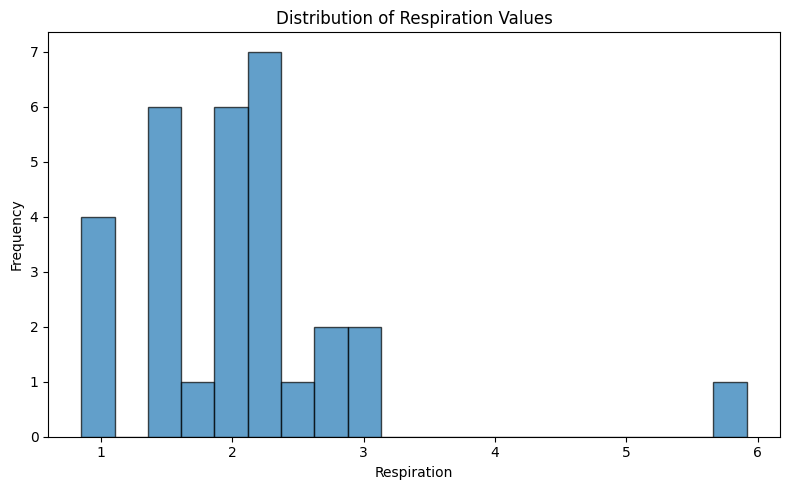

Respiration statistics:
count    30.000000
mean      2.066242
std       0.936155
min       0.849851
25%       1.550895
50%       1.971529
75%       2.267004
max       5.917205
Name: respiration, dtype: float64

Samples with respiration > Q3 + 1.5*IQR (potential outliers):
                  plate  respiration Fungal_Strain Nitrogen_Level
22  16_LE_N-10_3_MV.003     5.917205            LE           N-10


<Figure size 800x500 with 0 Axes>

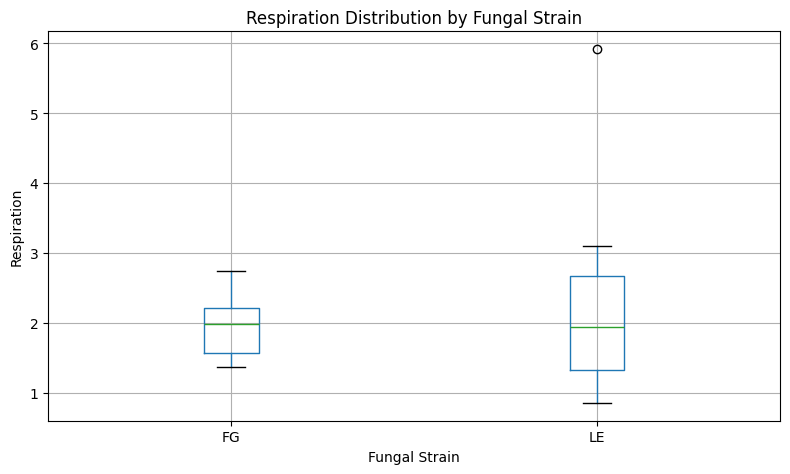

<Figure size 800x500 with 0 Axes>

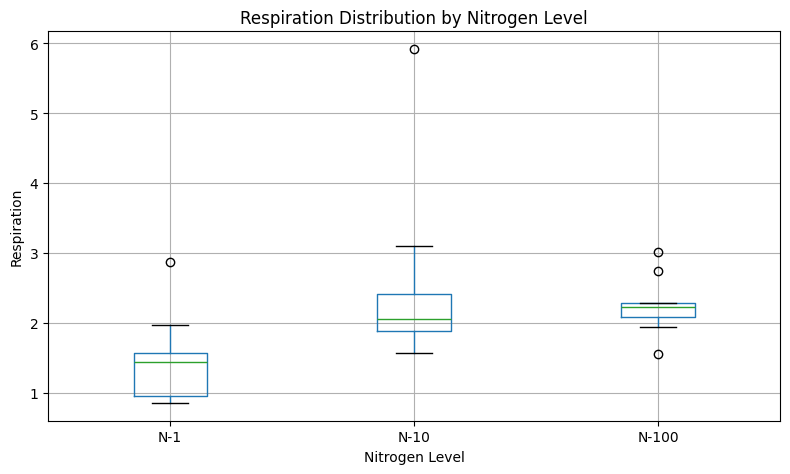

In [22]:
## Basic respiration distribution
plt.figure(figsize=(8, 5))
plt.hist(df_resp['respiration'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Respiration')
plt.ylabel('Frequency')
plt.title('Distribution of Respiration Values')
plt.tight_layout()
plt.show()

# Boxplot by fungal strain
plt.figure(figsize=(8, 5))
df_resp.boxplot(column='respiration', by='Fungal_Strain', figsize=(8, 5))
plt.xlabel('Fungal Strain')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Fungal Strain')
plt.suptitle('')  # Remove default title
plt.tight_layout()

# Identify potential outliers
print("Respiration statistics:")
print(df_resp['respiration'].describe())
print("\nSamples with respiration > Q3 + 1.5*IQR (potential outliers):")
Q1 = df_resp['respiration'].quantile(0.25)
Q3 = df_resp['respiration'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_resp[df_resp['respiration'] > Q3 + 1.5 * IQR]
print(outliers[['plate', 'respiration', 'Fungal_Strain', 'Nitrogen_Level']])
plt.show()

# Boxplot by nitrogen level
plt.figure(figsize=(8, 5))
df_resp.boxplot(column='respiration', by='Nitrogen_Level', figsize=(8, 5))
plt.xlabel('Nitrogen Level')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Nitrogen Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [23]:
print(np.sqrt((np.sum((df_resp['respiration']-np.mean(df_resp['respiration']))**2)))/len(df_resp))

0.1680449277381712


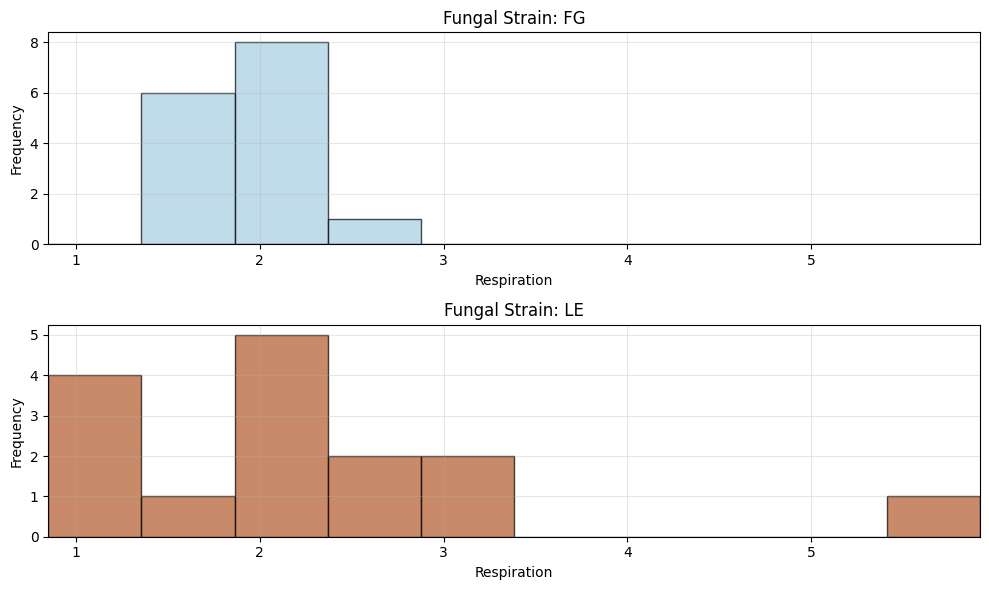

In [16]:
# Plot histograms by fungal strain in 2 rows with same x-axis
fungal_strains = sorted(df_resp['Fungal_Strain'].unique())
colors = plt.cm.Paired(np.linspace(0, 1, len(fungal_strains)))

# Get the range of respiration values for consistent x-axis
x_min = df_resp['respiration'].min()
x_max = df_resp['respiration'].max()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for idx, (strain, color) in enumerate(zip(fungal_strains, colors)):
    strain_data = df_resp[df_resp['Fungal_Strain'] == strain]['respiration']
    axes[idx].hist(strain_data, bins=10, edgecolor='black', alpha=0.7, color=color, range=(x_min, x_max))
    axes[idx].set_xlabel('Respiration')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Fungal Strain: {strain}')
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

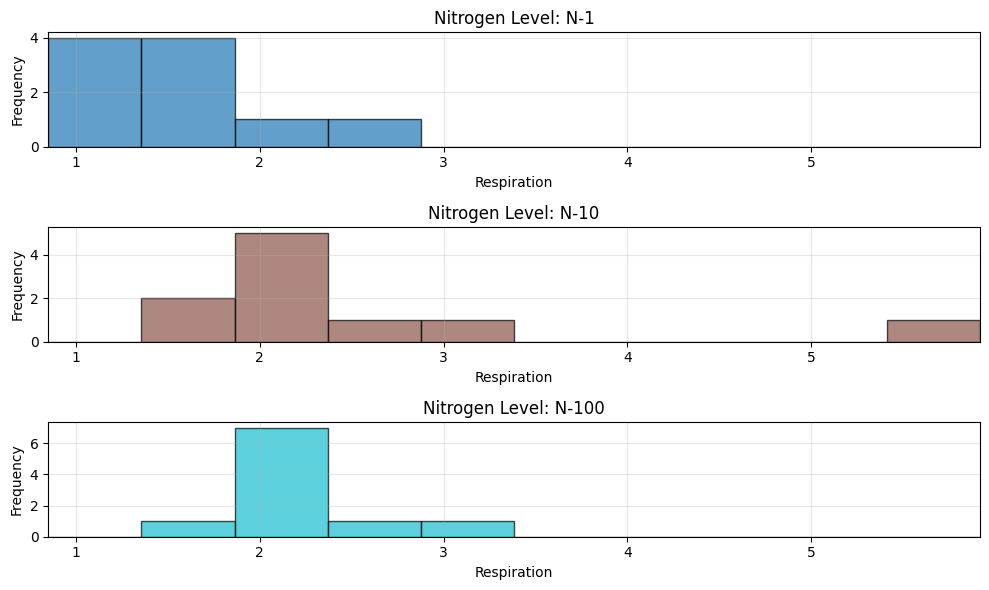

In [25]:
nitrogens = sorted(df_resp['Nitrogen_Level'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(nitrogens)))

# Get the range of respiration values for consistent x-axis
x_min = df_resp['respiration'].min()
x_max = df_resp['respiration'].max()

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

for idx, (nitro, color) in enumerate(zip(nitrogens, colors)):
    nitro_data = df_resp[df_resp['Nitrogen_Level'] == nitro]['respiration']
    axes[idx].hist(nitro_data, bins=10, edgecolor='black', alpha=0.7, color=color, range=(x_min, x_max))
    axes[idx].set_xlabel('Respiration')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Nitrogen Level: {nitro}')
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

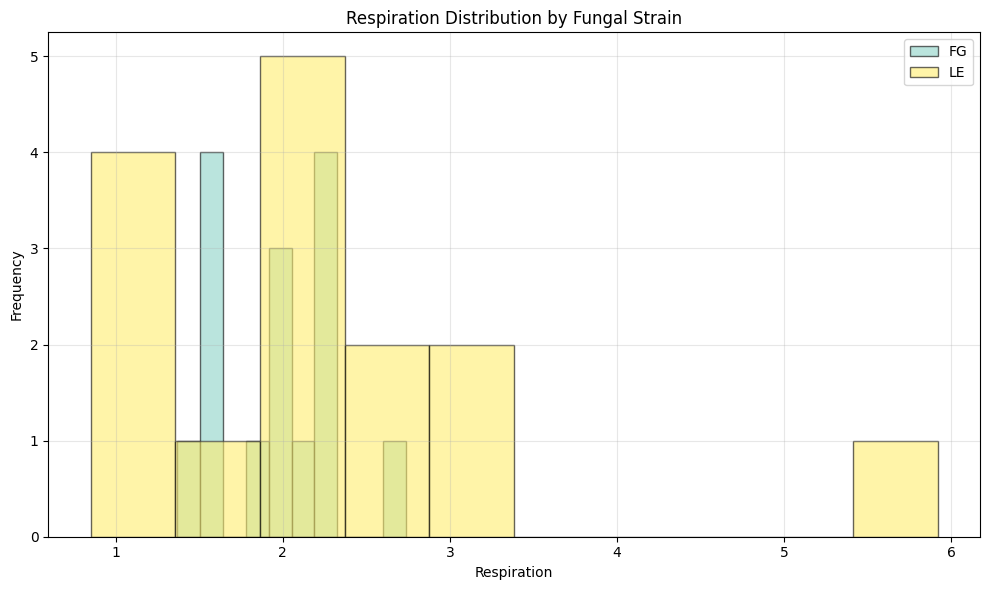

In [6]:
# Plot histograms by fungal strain in one plot
fungal_strains = sorted(df_resp['Fungal_Strain'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(fungal_strains)))

plt.figure(figsize=(10, 6))

for strain, color in zip(fungal_strains, colors):
    strain_data = df_resp[df_resp['Fungal_Strain'] == strain]['respiration']
    plt.hist(strain_data, bins=10, edgecolor='black', alpha=0.6, label=strain, color=color)

plt.xlabel('Respiration')
plt.ylabel('Frequency')
plt.title('Respiration Distribution by Fungal Strain')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Log transform 

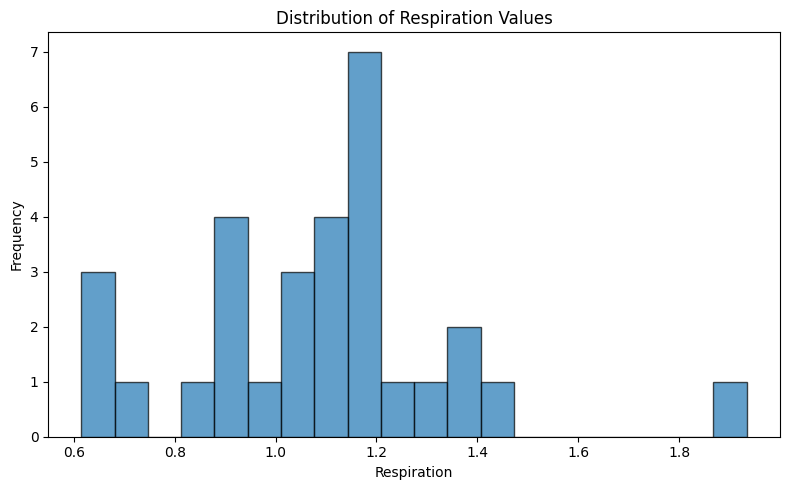

Respiration statistics:
count    30.000000
mean      1.084124
std       0.264665
min       0.615105
25%       0.936440
50%       1.089076
75%       1.183847
max       1.934012
Name: log_resp, dtype: float64

Samples with respiration > Q3 + 1.5*IQR (potential outliers):
                  plate  log_resp Fungal_Strain Nitrogen_Level
22  16_LE_N-10_3_MV.003  1.934012            LE           N-10


<Figure size 800x500 with 0 Axes>

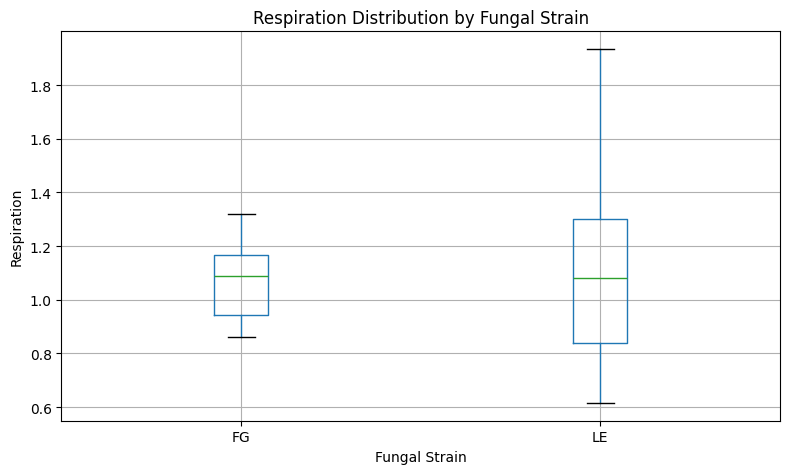

<Figure size 800x500 with 0 Axes>

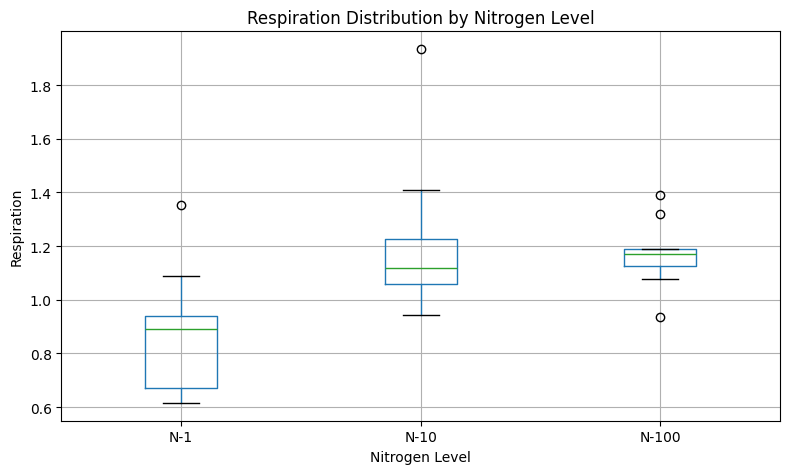

In [8]:
trait_target  = "log_resp"

## Basic respiration distribution
plt.figure(figsize=(8, 5))
plt.hist(df_resp[trait_target], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Respiration')
plt.ylabel('Frequency')
plt.title('Distribution of Respiration Values')
plt.tight_layout()
plt.show()

# Boxplot by fungal strain
plt.figure(figsize=(8, 5))
df_resp.boxplot(column=trait_target, by='Fungal_Strain', figsize=(8, 5))
plt.xlabel('Fungal Strain')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Fungal Strain')
plt.suptitle('')  # Remove default title
plt.tight_layout()

# Identify potential outliers
print("Respiration statistics:")
print(df_resp[trait_target].describe())
print("\nSamples with respiration > Q3 + 1.5*IQR (potential outliers):")
Q1 = df_resp[trait_target].quantile(0.25)
Q3 = df_resp[trait_target].quantile(0.75)
IQR = Q3 - Q1
outliers = df_resp[df_resp[trait_target] > Q3 + 1.5 * IQR]
print(outliers[['plate', trait_target, 'Fungal_Strain', 'Nitrogen_Level']])
plt.show()

# Boxplot by nitrogen level
plt.figure(figsize=(8, 5))
df_resp.boxplot(column=trait_target, by='Nitrogen_Level', figsize=(8, 5))
plt.xlabel('Nitrogen Level')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Nitrogen Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

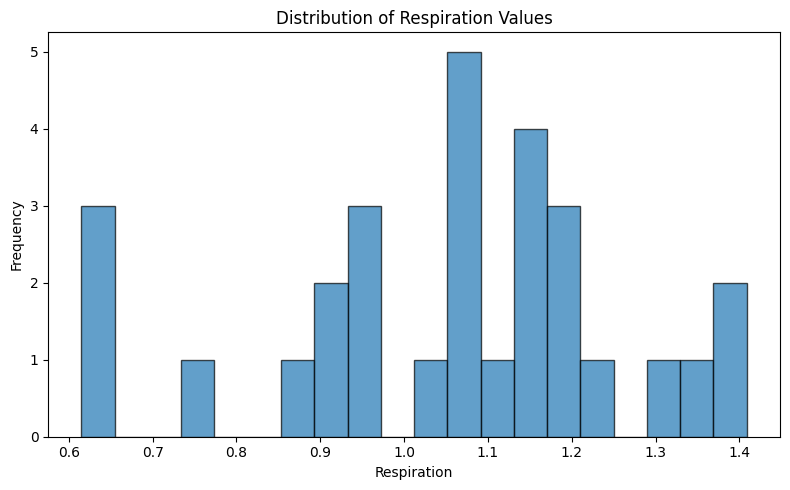

Respiration statistics:
count    29.000000
mean      1.054817
std       0.214156
min       0.615105
25%       0.934830
50%       1.088039
75%       1.171270
max       1.408818
Name: log_resp, dtype: float64

Samples with respiration > Q3 + 1.5*IQR (potential outliers):
Empty DataFrame
Columns: [plate, log_resp, Fungal_Strain, Nitrogen_Level]
Index: []


<Figure size 800x500 with 0 Axes>

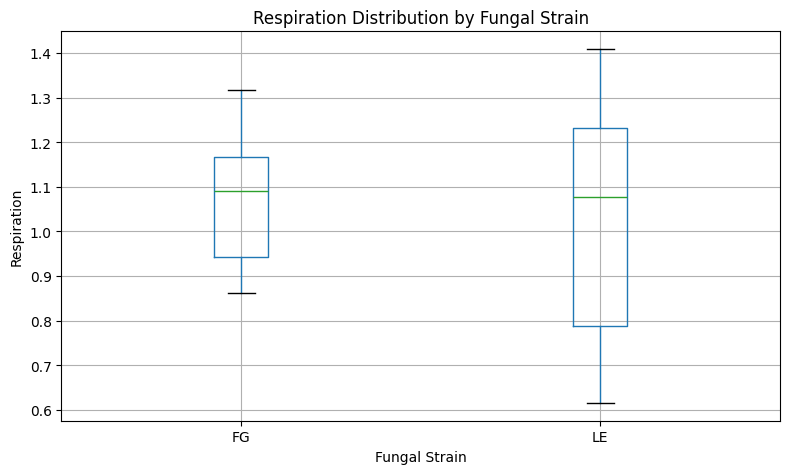

<Figure size 800x500 with 0 Axes>

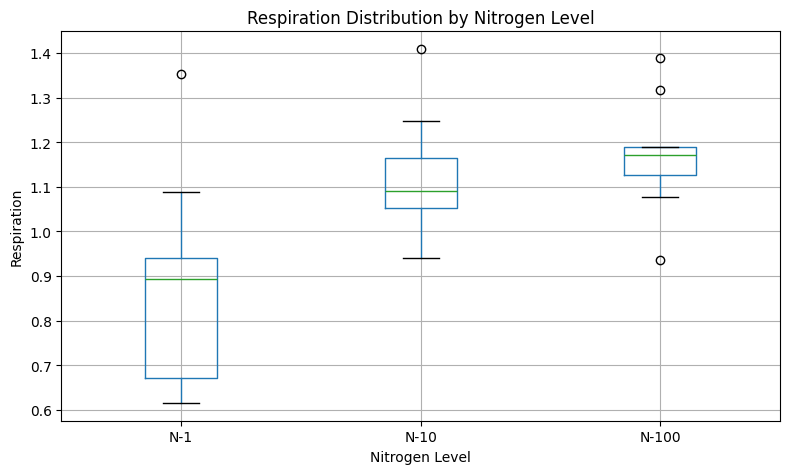

In [16]:
trait_target  = "log_resp"

## Basic respiration distribution
plt.figure(figsize=(8, 5))
plt.hist(df_resp_reduced[trait_target], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Respiration')
plt.ylabel('Frequency')
plt.title('Distribution of Respiration Values')
plt.tight_layout()
plt.show()

# Boxplot by fungal strain
plt.figure(figsize=(8, 5))
df_resp_reduced.boxplot(column=trait_target, by='Fungal_Strain', figsize=(8, 5))
plt.xlabel('Fungal Strain')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Fungal Strain')
plt.suptitle('')  # Remove default title
plt.tight_layout()

# Identify potential outliers
print("Respiration statistics:")
print(df_resp_reduced[trait_target].describe())
print("\nSamples with respiration > Q3 + 1.5*IQR (potential outliers):")
Q1 = df_resp_reduced[trait_target].quantile(0.25)
Q3 = df_resp_reduced[trait_target].quantile(0.75)
IQR = Q3 - Q1
outliers = df_resp_reduced[df_resp_reduced[trait_target] > Q3 + 1.5 * IQR]
print(outliers[['plate', trait_target, 'Fungal_Strain', 'Nitrogen_Level']])
plt.show()

# Boxplot by nitrogen level
plt.figure(figsize=(8, 5))
df_resp_reduced.boxplot(column=trait_target, by='Nitrogen_Level', figsize=(8, 5))
plt.xlabel('Nitrogen Level')
plt.ylabel('Respiration')
plt.title('Respiration Distribution by Nitrogen Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [9]:
print(np.sqrt((np.sum((df_resp[trait_target]-np.mean(df_resp[trait_target]))**2)))/len(df_resp))

0.047508755311500665


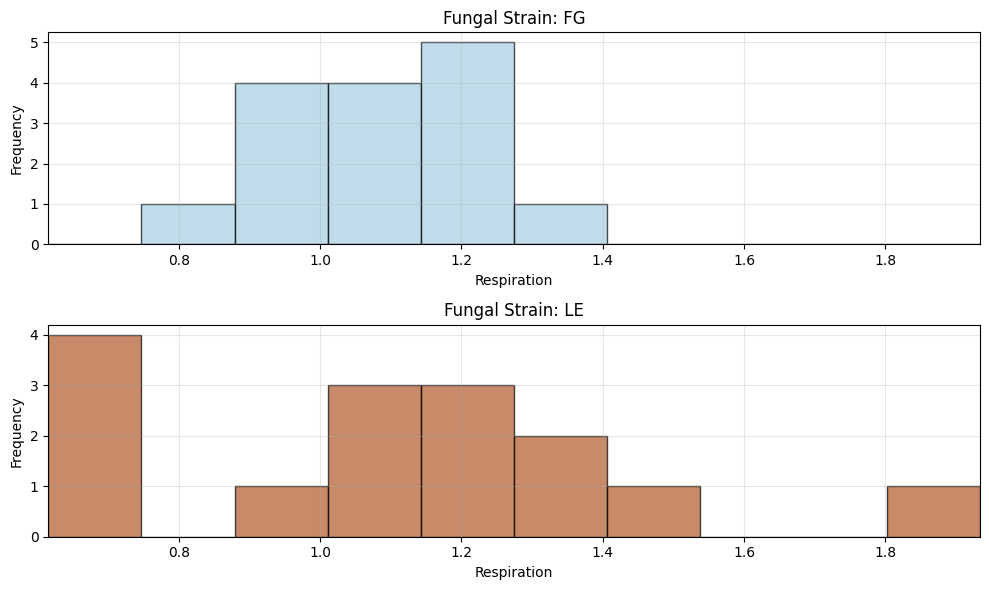

In [10]:
# Plot histograms by fungal strain in 2 rows with same x-axis
fungal_strains = sorted(df_resp['Fungal_Strain'].unique())
colors = plt.cm.Paired(np.linspace(0, 1, len(fungal_strains)))

# Get the range of respiration values for consistent x-axis
x_min = df_resp[trait_target].min()
x_max = df_resp[trait_target].max()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for idx, (strain, color) in enumerate(zip(fungal_strains, colors)):
    strain_data = df_resp[df_resp['Fungal_Strain'] == strain][trait_target]
    axes[idx].hist(strain_data, bins=10, edgecolor='black', alpha=0.7, color=color, range=(x_min, x_max))
    axes[idx].set_xlabel('Respiration')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Fungal Strain: {strain}')
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

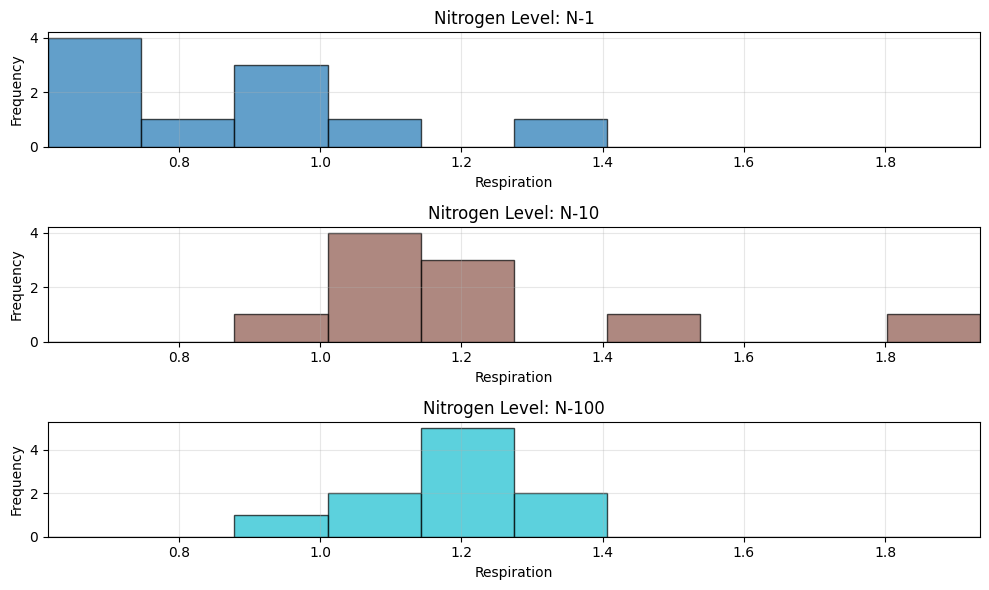

In [11]:
nitrogens = sorted(df_resp['Nitrogen_Level'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(nitrogens)))

# Get the range of respiration values for consistent x-axis
x_min = df_resp[trait_target].min()
x_max = df_resp[trait_target].max()

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

for idx, (nitro, color) in enumerate(zip(nitrogens, colors)):
    nitro_data = df_resp[df_resp['Nitrogen_Level'] == nitro][trait_target]
    axes[idx].hist(nitro_data, bins=10, edgecolor='black', alpha=0.7, color=color, range=(x_min, x_max))
    axes[idx].set_xlabel('Respiration')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Nitrogen Level: {nitro}')
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

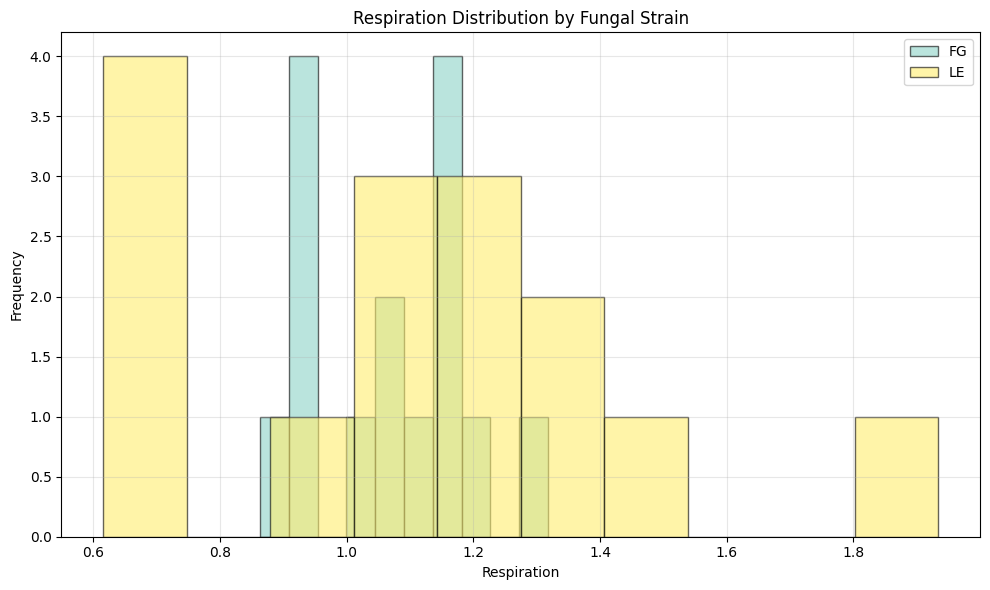

In [12]:
# Plot histograms by fungal strain in one plot
fungal_strains = sorted(df_resp['Fungal_Strain'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(fungal_strains)))

plt.figure(figsize=(10, 6))

for strain, color in zip(fungal_strains, colors):
    strain_data = df_resp[df_resp['Fungal_Strain'] == strain][trait_target]
    plt.hist(strain_data, bins=10, edgecolor='black', alpha=0.6, label=strain, color=color)

plt.xlabel('Respiration')
plt.ylabel('Frequency')
plt.title('Respiration Distribution by Fungal Strain')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()